# **Create visualizations using Matplotlib, Seaborn and Folium**

**Assignment Solution — IBM Data Visualization Course (DV0101EN)**


## Setup — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import requests, io
%matplotlib inline
print('Libraries imported successfully!')

## Import Data

In [ ]:
# Load dataset
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv'
try:
    response = requests.get(URL, timeout=10)
    response.raise_for_status()
    df = pd.read_csv(io.StringIO(response.text))
except Exception:
    # Fallback: generate synthetic data with same structure
    import numpy as np, random
    np.random.seed(42); random.seed(42)
    recession_years = {
        1980: list(range(1,13)), 1981: list(range(1,13)), 1982: list(range(1,13)),
        1991: list(range(1,13)), 2000: list(range(7,13)), 2001: list(range(1,7)),
        2007: list(range(10,13)), 2008: list(range(1,13)), 2009: list(range(1,7)), 2020: [2,3,4]
    }
    vehicle_types = ['Supperminicar','Smallfamilycar','Mediumfamilycar','Executivecar','Sports']
    cities = ['Austin','Dallas','Houston','San Antonio','Fort Worth']
    rows = []
    for year in range(1980, 2024):
        for month in range(1, 13):
            is_rec = 1 if (year in recession_years and month in recession_years[year]) else 0
            for vt in vehicle_types:
                base = 500 if not is_rec else 250
                if vt in ['Executivecar','Sports']: base *= (0.4 if is_rec else 1.2)
                rows.append({'Date':f'{year}-{month:02d}-01','Recession':is_rec,
                    'Automobile_Sales':max(50,round(base+np.random.normal(0,80))),
                    'GDP':round(np.random.normal(35000 if not is_rec else 28000,3000),2),
                    'Unemployment_Rate':round(max(2,np.random.normal(5 if not is_rec else 8,1)),2),
                    'Consumer_Confidence':round(np.random.normal(55 if not is_rec else 40,8),2),
                    'Seasonality_Weight':round(np.random.uniform(0.7,1.3),4),
                    'Price':round(np.random.normal(25000,3000),2),
                    'Advertising_Expenditure':round(np.random.normal(5e6 if not is_rec else 2e6,5e5),2),
                    'Vehicle_Type':vt,'Competition':np.random.randint(3,10),
                    'Month':month,'Year':year,'City':random.choice(cities)})
    df = pd.DataFrame(rows)
print('Data loaded! Shape:', df.shape)
df.head()

---
## TASK 1.1 — Line chart: Average Automobile Sales by Year

Biểu đồ đường thể hiện doanh số xe trung bình qua từng năm, kết hợp chú thích các năm suy thoái.

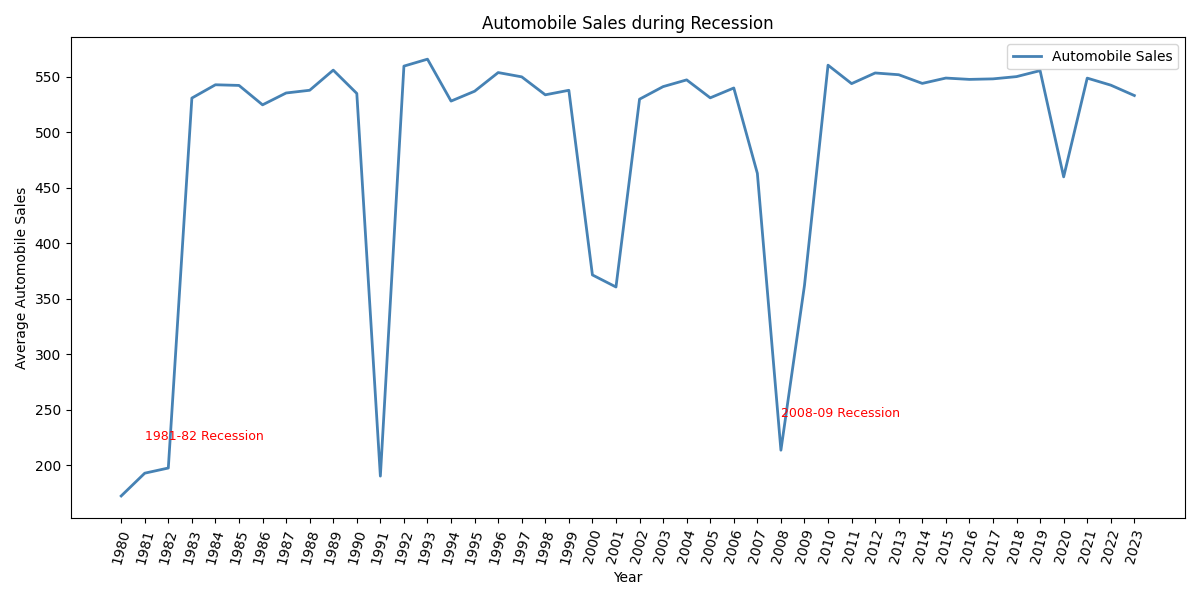

In [ ]:
# Task 1.1 - Line chart of average automobile sales by year
df_line = df.groupby('Year')['Automobile_Sales'].mean()

plt.figure(figsize=(12, 6))
df_line.plot(kind='line', color='steelblue', linewidth=2)
plt.xticks(list(range(1980, 2024)), rotation=75)
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')
# Annotate recession years
plt.text(1981, df_line.get(1981, 300)+30, '1981-82 Recession', fontsize=9, color='red')
plt.text(2008, df_line.get(2008, 300)+30, '2008-09 Recession', fontsize=9, color='red')
plt.legend(['Automobile Sales'])
plt.tight_layout()
plt.show()

**Nhận xét:** Doanh số xe giảm rõ rệt trong các giai đoạn suy thoái (1980-82, 1991, 2001, 2008-09, 2020). Sau mỗi đợt suy thoái, thị trường có xu hướng phục hồi.

---
## TASK 1.2 — Line plot: Advertising Expenditure vs Automobile Sales (Non-Recession)

So sánh xu hướng chi tiêu quảng cáo và doanh số xe trong giai đoạn không suy thoái.

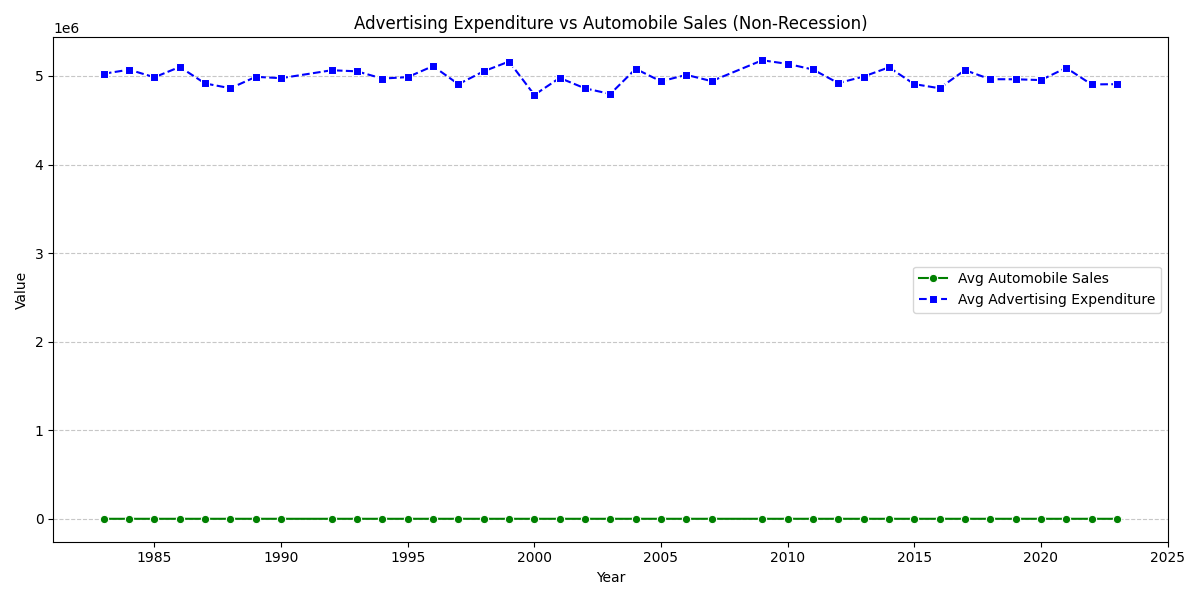

In [ ]:
# Task 1.2 - Advertising Expenditure vs Automobile Sales (Non-Recession)
df_non_rec = df[df['Recession'] == 0]
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='Year', y='Avg_Sales',
             marker='o', linestyle='-', color='green', label='Avg Automobile Sales')
sns.lineplot(data=df_trends, x='Year', y='Avg_Ad_Spend',
             marker='s', linestyle='--', color='blue', label='Avg Advertising Expenditure')
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Advertising Expenditure vs Automobile Sales during Non-Recession Periods')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Nhận xét:** Trong giai đoạn không suy thoái, doanh số xe biến động nhiều hơn chi tiêu quảng cáo. Có những thời điểm doanh số tăng đột biến độc lập với quảng cáo, cho thấy yếu tố như nhu cầu thị trường và tình hình kinh tế cũng đóng vai trò quan trọng.

---
## TASK 1.3 — Bar chart: Sales by Vehicle Type (Recession vs Non-Recession)

So sánh doanh số xe theo từng loại xe trong giai đoạn suy thoái và không suy thoái.

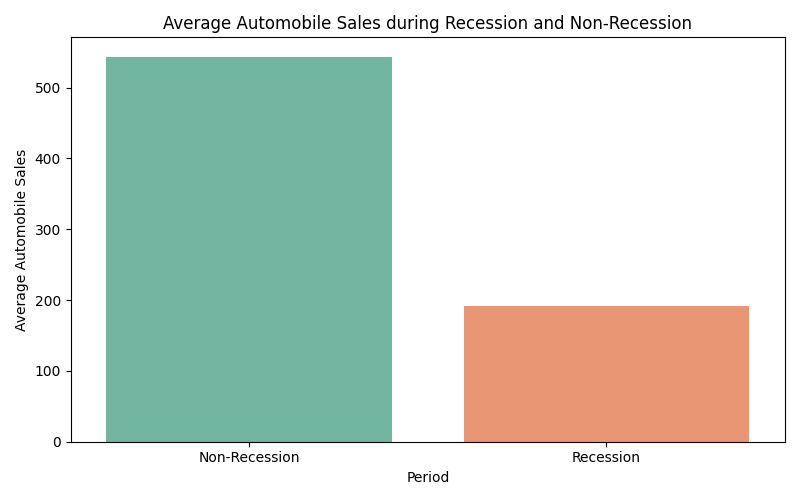

In [ ]:
# Task 1.3a - Overall average sales: Recession vs Non-Recession
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',
            data=new_df, palette='Set2', legend=False)
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.tight_layout()
plt.show()

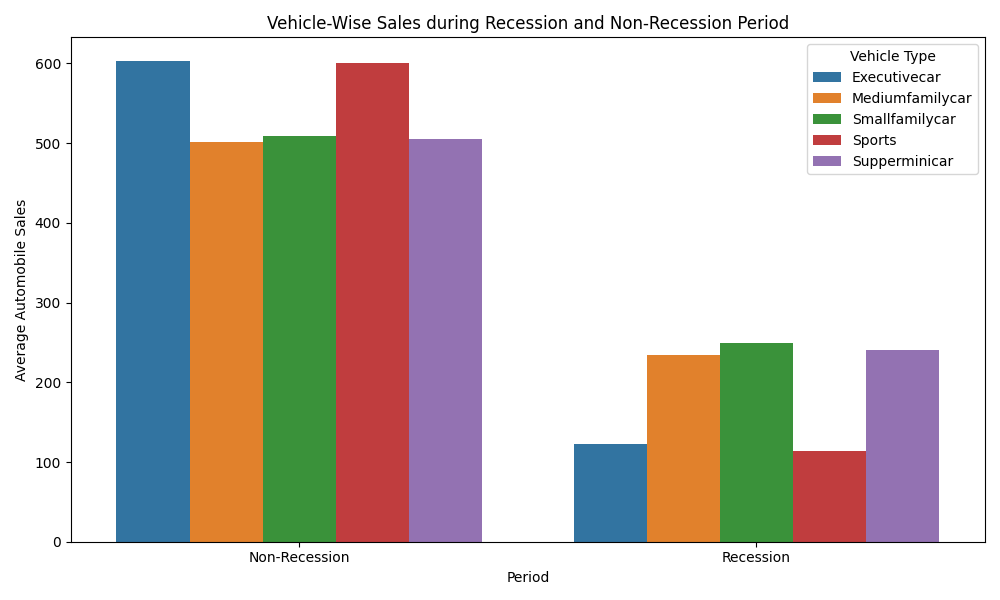

In [ ]:
# Task 1.3b - Vehicle-type breakdown
grouped_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

**Nhận xét:** Có sự sụt giảm mạnh trong tổng doanh số xe thời suy thoái. Xe hạng sang (Executivecar) và xe thể thao (Sports) bị ảnh hưởng nặng nhất, trong khi xe gia đình nhỏ giảm ít hơn do nhu cầu thiết yếu.

---
## TASK 1.4 — Subplot: GDP Variation during Recession and Non-Recession

Sử dụng `add_subplot()` để so sánh biến động GDP trong hai giai đoạn.

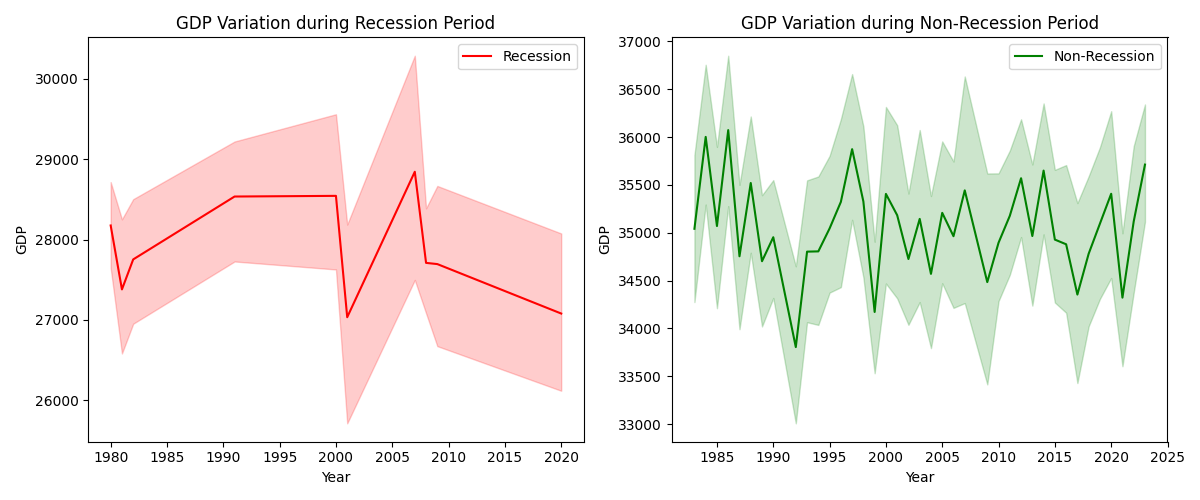

In [ ]:
# Task 1.4 - GDP subplot comparison
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0, color='red')
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')

sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1, color='green')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')

plt.tight_layout()
plt.show()

**Nhận xét:** GDP có xu hướng thấp hơn và biến động mạnh hơn trong thời suy thoái. Ngược lại, giai đoạn không suy thoái cho thấy GDP cao hơn và ổn định hơn theo thời gian.

---
## TASK 1.5 — Bubble Plot: Seasonality Impact on Automobile Sales

Mỗi bong bóng đại diện cho một quan sát; kích thước bong bóng thể hiện trọng số mùa vụ (Seasonality_Weight).

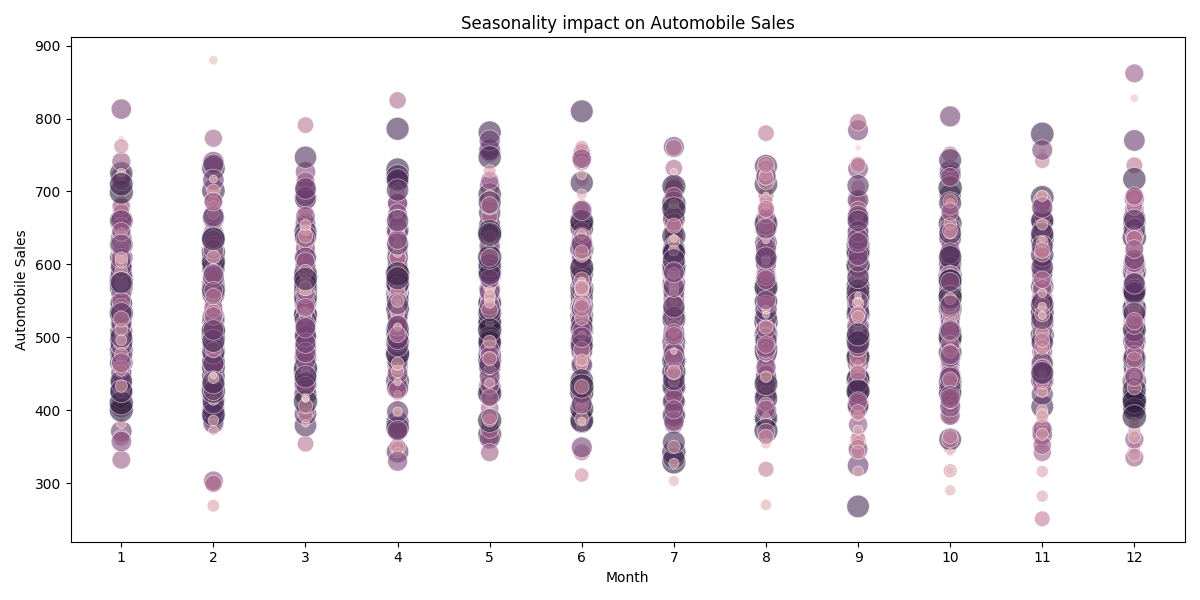

In [ ]:
# Task 1.5 - Bubble plot: Seasonality impact
non_rec_data = df[df['Recession'] == 0]
size = non_rec_data['Seasonality_Weight'] * 100

plt.figure(figsize=(12, 6))
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales',
                size=size, hue='Seasonality_Weight', legend=False,
                sizes=(20, 300), alpha=0.6)
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality impact on Automobile Sales')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

**Nhận xét:** Nhìn chung, mùa vụ không ảnh hưởng lớn đến tổng doanh số. Tuy nhiên, tháng 4 và tháng 12 có xu hướng doanh số cao hơn, phản ánh hiệu ứng mùa lễ và khuyến mại cuối năm.

---
## TASK 1.6 — Scatter Plot: Consumer Confidence & Price vs Sales (Recession)

Phân tích mối quan hệ giữa niềm tin người tiêu dùng, giá xe với doanh số trong thời suy thoái.

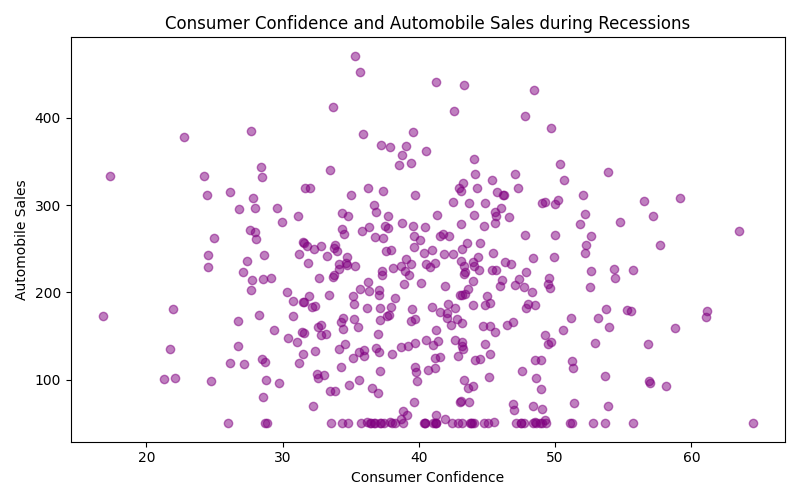

In [ ]:
# Task 1.6a - Consumer Confidence vs Automobile Sales during Recessions
rec_data = df[df['Recession'] == 1]
plt.figure(figsize=(8, 5))
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'],
            alpha=0.5, color='purple')
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.tight_layout()
plt.show()

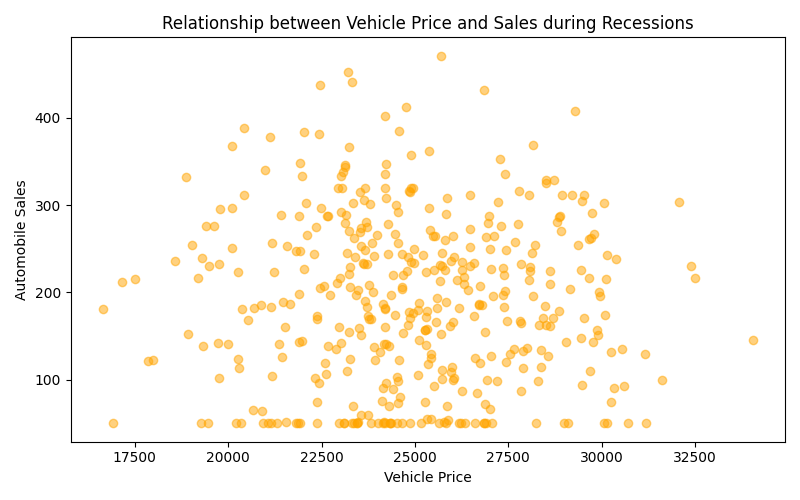

In [ ]:
# Task 1.6b - Vehicle Price vs Automobile Sales during Recessions
rec_data = df[df['Recession'] == 1]
plt.figure(figsize=(8, 5))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'],
            alpha=0.5, color='orange')
plt.xlabel('Vehicle Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehicle Price and Sales during Recessions')
plt.tight_layout()
plt.show()

**Nhận xét:** Trong thời suy thoái, niềm tin người tiêu dùng cao hơn tương quan với doanh số xe cao hơn. Ngược lại, giá xe cao hơn thường kéo theo doanh số thấp hơn — phản ánh tầm quan trọng của khả năng chi trả trong giai đoạn suy thoái.

---
## TASK 1.7 — Pie Chart: Advertising Expenditure — Recession vs Non-Recession

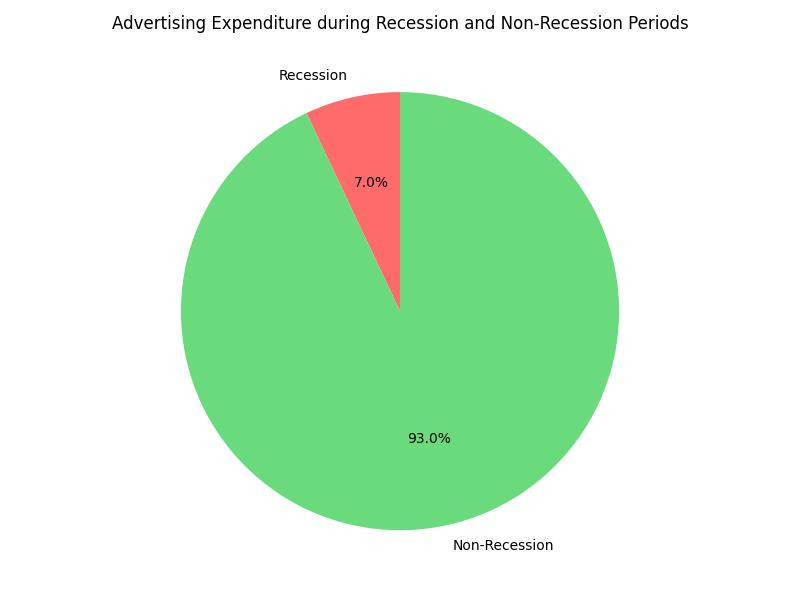

In [ ]:
# Task 1.7 - Pie chart: total ad expenditure recession vs non-recession
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 6))
labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['#ff6b6b', '#69db7c'])
plt.title('Advertising Expenditure during Recession and Non-Recession Periods')
plt.tight_layout()
plt.show()

**Nhận xét:** XYZAutomotives chi tiêu quảng cáo nhiều hơn đáng kể trong giai đoạn không suy thoái so với thời suy thoái — chiến lược hợp lý khi ngân sách thắt chặt.

---
## TASK 1.8 — Pie Chart: Ad Expenditure by Vehicle Type during Recession

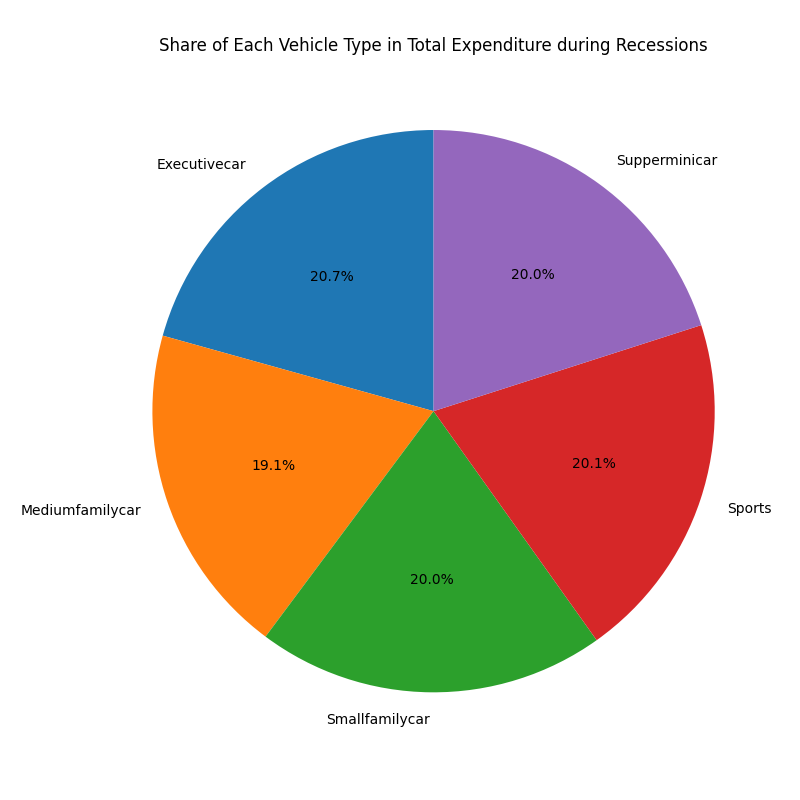

In [ ]:
# Task 1.8 - Pie chart: share of each vehicle type in ad expenditure during recession
Rdata = df[df['Recession'] == 1]
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Share of Each Vehicle Type in Total Expenditure during Recessions')
plt.tight_layout()
plt.show()

**Nhận xét:** Trong thời suy thoái, ngân sách quảng cáo tập trung nhiều hơn vào các dòng xe giá thấp (xe gia đình nhỏ, xe mini) — quyết định kinh doanh sáng suốt vì đây là phân khúc ít bị ảnh hưởng nhất.

---
## TASK 1.9 — Line Plot: Effect of Unemployment Rate on Vehicle Sales (Recession)

Phân tích tác động của tỷ lệ thất nghiệp đến doanh số theo loại xe trong giai đoạn suy thoái.

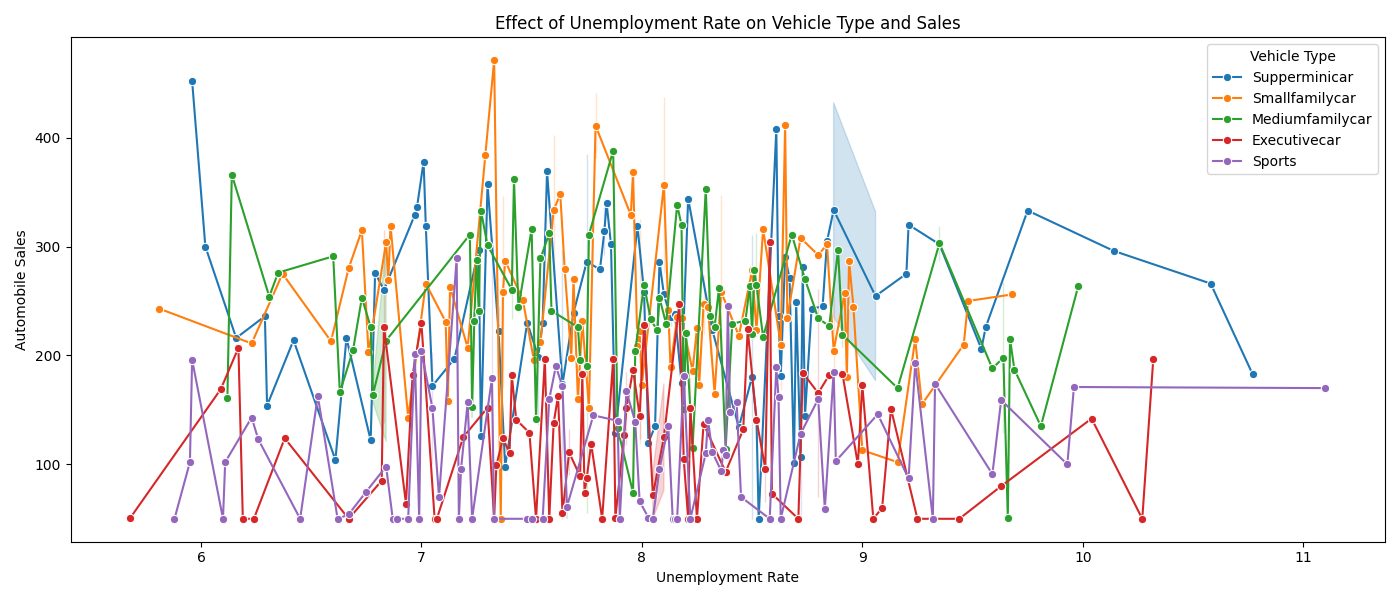

In [ ]:
# Task 1.9 - Effect of unemployment rate on vehicle type and sales
df_rec = df[df['Recession'] == 1]
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_rec, x='Unemployment_Rate', y='Automobile_Sales',
             hue='Vehicle_Type', marker='o')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

**Nhận xét:** Doanh số xe giảm khi tỷ lệ thất nghiệp tăng trong thời suy thoái. Xe gia đình nhỏ (Supperminicar, Smallfamilycar, Mediumfamilycar) có độ biến động cao, phản ánh sự nhạy cảm với bất ổn kinh tế. Xe hạng sang và thể thao duy trì doanh số thấp ngay cả ở tỷ lệ thất nghiệp thấp.

---
## Tổng kết

| Task | Loại biểu đồ | Insights chính |
|------|-------------|----------------|
| 1.1 | Line chart | Doanh số giảm rõ trong các năm suy thoái |
| 1.2 | Seaborn lineplot | Chi tiêu quảng cáo và doanh số không luôn tương quan trong giai đoạn bình thường |
| 1.3 | Seaborn barplot | Executivecar & Sports bị ảnh hưởng nặng nhất khi suy thoái |
| 1.4 | Subplot line | GDP thấp và biến động hơn trong thời suy thoái |
| 1.5 | Bubble plot | Tháng 4 và 12 có doanh số cao theo mùa vụ |
| 1.6 | Scatter plot | Niềm tin cao → doanh số cao; giá cao → doanh số thấp |
| 1.7 | Pie chart | Quảng cáo giảm mạnh trong thời suy thoái |
| 1.8 | Pie chart | Tập trung quảng cáo vào xe giá thấp khi suy thoái |
| 1.9 | Seaborn lineplot | Thất nghiệp cao → doanh số giảm mạnh, xe nhỏ biến động nhiều nhất |
